In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator # Correct import path
import matplotlib.pyplot as plt
import numpy as np
def aumentarImagenes(img_array,n,plotear=False):

  img_array = np.expand_dims(img_array, axis=0)  # Agrega una dimensión para el batch
# Crea un generador de aumento de datos
  datagen = ImageDataGenerator(
    rotation_range=45,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Genera imágenes aumentadas
  i = 0
  images = []
  for batch in datagen.flow(img_array, batch_size=1):
    # Muestra o guarda la imagen aumentada
    if plotear:
      plt.figure(i)
      plt.imshow(batch[0])
    images.append(batch[0])
    i += 1
    if i > n:  # Genera 5 imágenes aumentadas
      break
  if plotear:
    plt.show()

  return images

In [ ]:
from sklearn.model_selection import train_test_split
#Carga de librerias
from PIL import Image
import os
import numpy as np

# Ruta a la carpeta que contiene las imágenes
folder_path = 'C:/Users/maite/LastTry/dataframe'
# Lista para almacenar las imágenes cargadas
image_list = []
#Lista para almacenar las etiquetas
y = []
# Recorre todos los archivos en la carpeta
for filename in os.listdir(folder_path): # Bellota, Edd, Gwen, Mandy, Raven
    if 'Bellota' in filename: #indice 0 Bellota
      y.append(0)
      val = 0
    elif 'Edd' in filename: #indice 1 Edd
      y.append(1)
      val = 1
    elif 'Gwen' in filename: #indice 2 Gwen
      y.append(2)
      val = 2
    elif 'Mandy' in filename: #indice 3 Mandy
      y.append(3)
      val = 3
    elif 'Raven' in filename: #indice 4 Raven
      y.append(4)
      val = 4
    if filename.endswith(".jpg") or filename.endswith(".png") or filename.endswith(".jpeg"):
        img_path = os.path.join(folder_path, filename)
        img = Image.open(img_path)
        img = img.resize((224, 224))  # Redimensiona la imagen
        img_array = np.array(img) / 255.0  # Normaliza los valores de píxeles
        image_list.append(img_array)
        aumentadas = aumentarImagenes(img_array,2,True)
        image_list.extend(aumentadas)
        for i in range(len(aumentadas)):
          y.append(val)

X_train, X_test, y_train, y_test = train_test_split(image_list, y, test_size=0.25, random_state=42, stratify=y)
len(X_train), len(X_test), len(y_train), len(y_test)

In [4]:
#Cambiamos la forma
import numpy as np

#Cambiamos la forma
# Preprocesar X_train para asegurar que todas las imágenes tengan 3 canales
processed_X_train = []
for img_array in X_train:
    if img_array.ndim == 3: # Check if it already has channel dimension
        if img_array.shape[-1] == 4: # If RGBA (4 channels), take only the first 3 (RGB)
            processed_X_train.append(img_array[:, :, :3])
        elif img_array.shape[-1] == 3: # If RGB (3 channels), append directly
            processed_X_train.append(img_array)
        elif img_array.shape[-1] == 1: # If grayscale (1 channel), repeat to get 3 channels
            processed_X_train.append(np.repeat(img_array, 3, axis=-1))
        else: # For any other unexpected channel count, append as is (may still cause issues if not 3)
            processed_X_train.append(img_array)
    elif img_array.ndim == 2: # If grayscale (H, W), stack to create (H, W, 3)
        processed_X_train.append(np.stack([img_array, img_array, img_array], axis=-1))
    else: # For any other unexpected dimensions, append as is
        processed_X_train.append(img_array)

X_train = np.array(processed_X_train)
y_train = np.array(y_train)

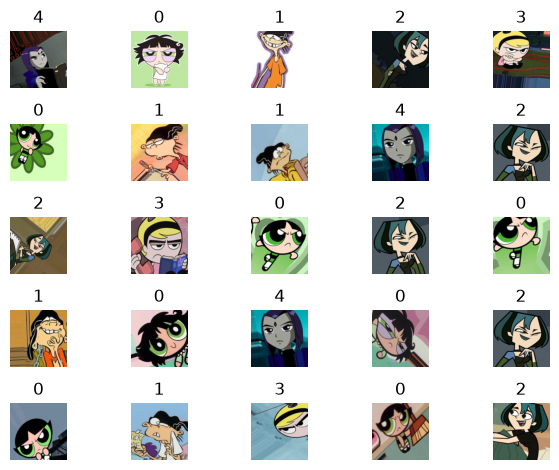

In [5]:
import matplotlib.pyplot as plt
import random

fig = plt.figure(dpi=100)
for ix in range(25):
	ax = plt.subplot(5, 5, ix + 1)
	i = random.randint(0, len(X_train)-1)
	img, label = X_train[i], y_train[i]
	ax.imshow(img.reshape(224,224,3), cmap='gray')
	ax.set_title(label)
	ax.axis('off')
plt.tight_layout()
plt.show()

En nuestra primera iteración, haremos un clasificador binario sencillo que detecte sólo el número 3. Más adelante iremos complicando los requisitos, lo cual nos dará opción a generar diferentes versiones de nuestro dataset y así ver un ejemplo de las herramientas necesarias para ello. Además, nos quedaremos con una pequeña muestra para empezar con un dataset limitado.

In [6]:
import numpy as np

X_train_0 = X_train[y_train == 0][:50]
X_train_1 = X_train[y_train == 1][:50]
X_train_2 = X_train[y_train == 2][:50]
X_train_3 = X_train[y_train == 3][:50]
X_train_4 = X_train[y_train == 4][:50]

len(X_train_0), len(X_train_1), len(X_train_2), len(X_train_3), len(X_train_4)

(50, 50, 50, 50, 50)

In [7]:
def plot_samples(X):
	fig = plt.figure(dpi=100)
	for ix in range(25):
		ax = plt.subplot(5, 5, ix + 1)
		i = random.randint(0, len(X)-1)
		img = X[i]
		ax.imshow(img.reshape(224,224,3), cmap='gray')
		ax.axis('off')
	plt.tight_layout()
	plt.show()

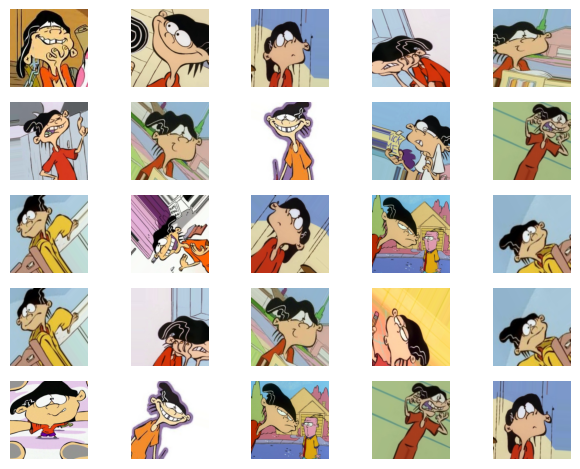

In [8]:
plot_samples(X_train_1)

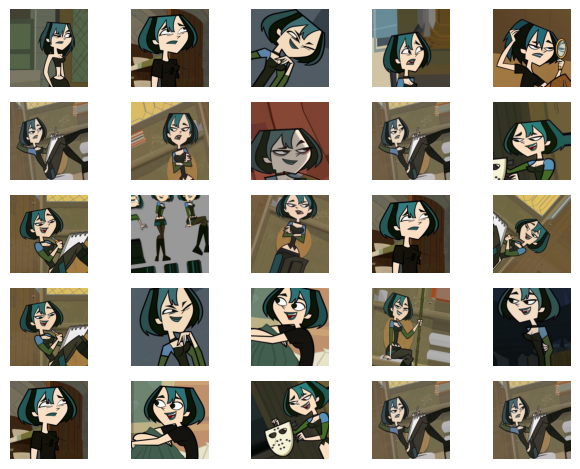

In [9]:
plot_samples(X_train_2)

Ahora guardaremos las imágenes en sendas carpetas, separando además un 20% de las muestras para el conjunto de test. A medida que nuestra aplicación vaya creciendo y siendo usada cada vez más deberemos identificar aquellos ejemplos en los que falla, etiquetarlo e incluirlos en el conjunto de test. Por otro lado, deberemos recoger ejemplos similares, etiquetarlos y añadirlos al conjunto de entrenamiento. De este manera, al re-entrenar los modelos, nos aseguraremos de ir corrigiendo errores de manera adecuada (este proceso se conoce como *active learning*).

In [11]:
import os
from pathlib import Path
from skimage.io import imsave
import shutil

path = Path('dataset')

def generate_dataset(X_train_0, X_train_1, X_train_2, X_train_3, X_train_4, test_size):
	if path.exists():
		try:
			shutil.rmtree(path)
		except PermissionError:
			import time
			time.sleep(0.5)  # Wait briefly for file locks to release
			shutil.rmtree(path, ignore_errors=True)
	os.makedirs(path, exist_ok=True)

	splits = ['train', 'test']
	for split in splits:
		os.makedirs(path / split, exist_ok=True)
		os.makedirs(path / split / '0', exist_ok=True)
		os.makedirs(path / split / '1', exist_ok=True)
		os.makedirs(path / split / '2', exist_ok=True)
		os.makedirs(path / split / '3', exist_ok=True)
		os.makedirs(path / split / '4', exist_ok=True)
		if split == 'train':
			X1, X2, X3, X4, X5 = X_train_0[:-test_size], X_train_1[:-test_size], X_train_2[:-test_size], X_train_3[:-test_size], X_train_4[:-test_size]
		else:
			X1, X2, X3, X4, X5 = X_train_0[-test_size:], X_train_1[-test_size:], X_train_2[-test_size:], X_train_3[-test_size:], X_train_4[-test_size:]
		for x1, x2, x3, x4, x5 in zip(X1, X2, X3, X4, X5):
			imsave(path / split / '0' / f'{random.randint(0, 99999):05d}.png', (x1.reshape(224, 224, 3) * 255).astype('uint8'))
			imsave(path / split / '1' / f'{random.randint(0, 99999):05d}.png', (x2.reshape(224, 224, 3) * 255).astype('uint8'))
			imsave(path / split / '2' / f'{random.randint(0, 99999):05d}.png', (x3.reshape(224, 224, 3) * 255).astype('uint8'))
			imsave(path / split / '3' / f'{random.randint(0, 99999):05d}.png', (x4.reshape(224, 224, 3) * 255).astype('uint8'))
			imsave(path / split / '4' / f'{random.randint(0, 99999):05d}.png', (x5.reshape(224, 224, 3) * 255).astype('uint8'))

In [12]:
generate_dataset(X_train_0, X_train_1, X_train_2, X_train_3, X_train_4, 20)

In [13]:
from glob import glob

def get_paths():
	train_0 = glob(str(path / 'train' / '0' / '*.png'))
	train_1 = glob(str(path / 'train' / '1' / '*.png'))
	train_2 = glob(str(path / 'train' / '2' / '*.png'))
	train_3 = glob(str(path / 'train' / '3' / '*.png'))
	train_4 = glob(str(path / 'train' / '4' / '*.png'))
	test_0 = glob(str(path / 'test' / '0' / '*.png'))
	test_1 = glob(str(path / 'test' / '1' / '*.png'))
	test_2 = glob(str(path / 'test' / '2' / '*.png'))
	test_3 = glob(str(path / 'test' / '3' / '*.png'))
	test_4 = glob(str(path / 'test' / '4' / '*.png'))
	return train_0, train_1, train_2, train_3, train_4, test_0, test_1, test_2, test_3, test_4

train_0, train_1, train_2, train_3, train_4, test_0, test_1, test_2, test_3, test_4 = get_paths()

len(train_0), len(train_1), len(train_2), len(train_3), len(train_4), len(test_0), len(test_1), len(test_2), len(test_3), len(test_4)

(30, 30, 30, 30, 30, 20, 20, 20, 20, 20)

In [14]:
from skimage.io import imread

def plot_images(paths):
	fig = plt.figure(dpi=100)
	for ix in range(25):
		ax = plt.subplot(5, 5, ix + 1)
		i = random.randint(0, len(paths)-1)
		img = imread(paths[i])
		ax.imshow(img, cmap='gray')
		ax.axis('off')
	plt.tight_layout()
	plt.show()

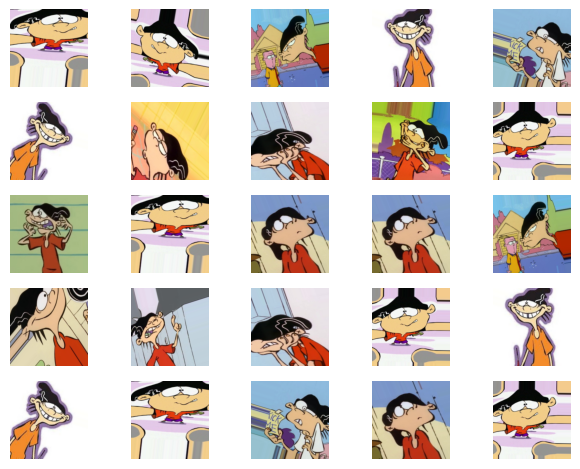

In [15]:
plot_images(train_1)

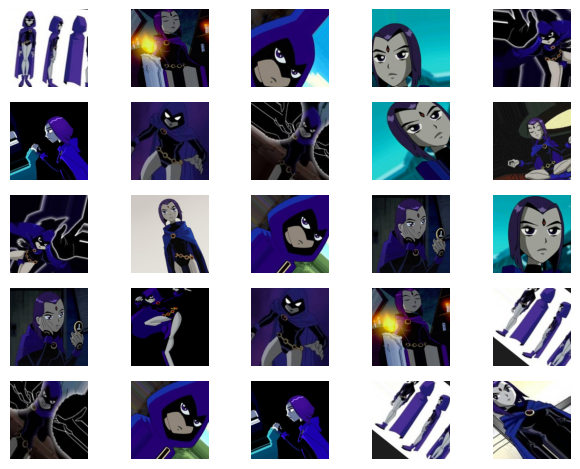

In [46]:
plot_images(train_4)

## Versionado de datos

En este punto hemos generado una primera versión de nuestro dataset que queremos usar para entrenar nuestro primero modelo. Sabemos que en el futuro el dataset irá evolucionando, añadiendo más ejemplos y clases (y en función de la aplicación potencialmente nuevas tareas). La opción más sencilla para manejar esto sería generar un `.zip` con nuestros datos, ponerle un nombre (por ejemplo, mnist-v1.0) y guardarlo en algún servidor al cual puedan acceder los ingeniero de *deep learning* para entrenar modelos. Lo mismo podríamos hacer en el software 1.0 con nuestro código (y durante mucho tiempo así se hizo, incluso quizás hay empresas que aún lo hacen 😂) sin embargo hace tiempo que aprendimos que el uso de herramientas de `control de versión` son mucho más útiles y eficaces. El ejemplo principal es `git`. Así pues, para manejar nuestros datos (y más adelante modelos, métricas e incluso `pipelines` de entrenamiento) usaremos una herramienta de `control de versión` específica para trabajar con grandes datos en entornos de *machine learning* conocida como [dvc](https://dvc.org/). `dvc` trabaja en conjunto con `git`, así que lo primero que necesitaremos será un repositorio de `git`, que puedes alojar en `Github`, para manejar el proyecto.

> En mi caso he creado este [repo](https://github.com/juansensio/dlops) que usaré durante toda la serie de posts.

Puedes instalar `dvc` con el siguiente comando:

```
pip install dvc
```

Acto seguido, inicializaremos un repositorio con el comando:

```
dvc init
```

Deberás ejectuar el comando al mismo nivel que el de git, ya que `dvc` utiliza git para el control de version de los metadatos asociados a los datos (archivos grandes). Esto generará una carpeta `.dvc` y un archivo `.dvcignore` similar a git. Ahora podemos añadir la carpeta con los datos al repositorio con el comando

```
dvc add dataset
```

El siguiente paso será conectar `dvc` con un servicio de almacenamiento remoto en el que guardar nuestros datos. Puedes utilizar diferentes servicios, [aquí](https://dvc.org/features) tienes una lista. En este caso utilizaremos [firebase](https://firebase.google.com/), ya que más adelante usaremos otras características como la base de datos. Para que `dvc` pueda acceder al `bucket` necesitaremos configurar la variable de entorno `GOOGLE_APPLICATION_CREDENTIALS`, siguiendo la [documentación](https://cloud.google.com/docs/authentication/getting-started#command-line) o descargando las credenciales desde la consola de firebase. Una vez conectado, podremos sincronizar nuestro dataset con el comando:

```
dvc push
```

Ahora puedes probar a eliminar la carpeta `dataset` y para volver a recuperarla puedes ejecutar

```
dvc pull dataset.dvc
```

Usaremos `git` para crear una nueva versión con el comando

```
git tag -a v0 -m "version 0"
```

`git` guardará los archivos específicos de `dvc` del commit con el tag determinado.

```
git add .
git commit -m "primera versión"
git push
git push origin --tags
```

En este punto, cualquiera con acceso al repositorio de `git` y `dvc` (con las credenciales necesarias de `firebase`) podrá acceder al dataset y a todas sus versiones de manera sencilla y remota para usarlo para entrenar modelos o modificarlo y crear nuevas versiones.

```
dvc pull
```

## Creando nuevas versiones

Ahora vamos a generar una nueva versión del dataset con 100 muestras más de las que teníamos anteriormente.

In [16]:
#X_train_3 = X_train[y_train == '3'][:200]
#X_train_no_3 = X_train[y_train != '3'][:200]

#len(X_train_3), len(X_train_no_3)

X_train_0 = X_train[y_train == 0][:60]
X_train_1 = X_train[y_train == 1][:60]
X_train_2 = X_train[y_train == 2][:60]
X_train_3 = X_train[y_train == 3][:60]
X_train_4 = X_train[y_train == 4][:60]

len(X_train_0), len(X_train_1), len(X_train_2), len(X_train_3), len(X_train_4)

(60, 60, 60, 60, 60)

In [17]:
#generate_dataset(X_train_3, X_train_no_3, 40)
generate_dataset(X_train_0, X_train_1, X_train_2, X_train_3, X_train_4, 20)

In [18]:
#train_3, train_no3, test_3, test_no3 = get_paths()

#len(train_3), len(train_no3), len(test_3), len(test_no3)

train_0, train_1, train_2, train_3, train_4, test_0, test_1, test_2, test_3, test_4 = get_paths()

len(train_0), len(train_1), len(train_2), len(train_3), len(train_4), len(test_0), len(test_1), len(test_2), len(test_3), len(test_4)

(40, 40, 40, 40, 40, 20, 20, 20, 20, 20)

Utilizaremos los comando vistos anteriormente para crear una nueva versión:

```
dvc add dataset
dvc push
git add .
git commit -m 'nueva version'
git push
git tag -a v1 -m "version 1"
git push origin --tags
```

Ahora que tenemos diferentes versiones podemos ir cambiando entre ellas de la siguiente manera.

```
git checkout tags/v0
dvc pull
```

In [ ]:
# versión 0 con 80/20 split

train_0, train_1, train_2, train_3, train_4, test_0, test_1, test_2, test_3, test_4 = get_paths()

len(train_0), len(train_1), len(train_2), len(train_3), len(train_4), len(test_0), len(test_1), len(test_2), len(test_3), len(test_4)

```
git checkout tags/v1
dvc pull
```

In [ ]:
# versión 1 con 160/40 split

train_3, train_no3, test_3, test_no3 = get_paths()

len(train_3), len(train_no3), len(test_3), len(test_no3)

## Resumen

En este post hemos aprendido a usar la herramienta de control de versiones [`dvc`](https://dvc.org/), la cual hemos usado para versionar nuestro dataset pero que también usaremos más adelante para versionar modelos, métricas e incluso `pipelines` completas de entrenamiento muy útiles para automatización. En este ejemplo hemos visto como generar varias versiones de un dataset para clasificación binaria de dígitos manuscritos que usaremos de ahora en adelante a medida que vayamos introduciendo técnicas y herramientas de DLOps y el cual iremos modificando (y versionando), añadiendo más ejemplos y más clases.